# Exploratory Data Analysis (EDA) Notebook  
## NABIL Bank Stock Price Prediction Using NEPSE Data

This notebook is designed for the **nepse-ml-pipeline** project.  
It loads the raw NABIL CSV and the processed feature table, performs EDA, saves report-ready charts, and creates a small text summary that can be adapted into the final report.

**Recommended use in the report:**  
Place the strongest outputs from this notebook after **Section 3.3 Feature Engineering** as a new section called **3.4 Exploratory Data Analysis and Insights**.  
Use only the most meaningful figures, not every chart.

## 1. Setup and Project Path Detection

Run this notebook from either:

- the project root folder: `nepse-ml-pipeline/`, or  
- the notebooks folder: `nepse-ml-pipeline/notebooks/`.

The code automatically tries to locate the project root and output folder.

In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def find_project_root(start_path=None):
    """Find the nepse-ml-pipeline root by checking common project files/folders."""
    start = Path(start_path or os.getcwd()).resolve()
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        has_data = (candidate / "data").exists()
        has_scripts = (candidate / "scripts").exists()
        has_readme = (candidate / "README.md").exists()
        if has_data and (has_scripts or has_readme):
            return candidate
    return start

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("EDA figures will be saved to:", OUTPUT_DIR)

Matplotlib is building the font cache; this may take a moment.


Project root: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline
EDA figures will be saved to: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda


## 2. Load Raw and Processed Data

The project contains:

- `data/raw/NABIL.csv`  
- `data/processed/nabil_features.csv`

If these exact files are not found, the notebook searches the project folder for similar file names.

In [2]:
def find_file(preferred_path, fallback_patterns):
    preferred_path = Path(preferred_path)
    if preferred_path.exists():
        return preferred_path

    for pattern in fallback_patterns:
        matches = list(PROJECT_ROOT.rglob(pattern))
        if matches:
            return matches[0]

    raise FileNotFoundError(f"Could not find {preferred_path.name}. Checked fallback patterns: {fallback_patterns}")

RAW_PATH = find_file(
    RAW_DIR / "NABIL.csv",
    ["*NABIL*.csv", "*nabil*.csv"]
)

FEATURES_PATH = find_file(
    PROCESSED_DIR / "nabil_features.csv",
    ["*nabil_features*.csv", "*features*.csv"]
)

raw = pd.read_csv(RAW_PATH)
features = pd.read_csv(FEATURES_PATH)

print("Raw data path:", RAW_PATH)
print("Processed features path:", FEATURES_PATH)
print("Raw data shape:", raw.shape)
print("Processed features shape:", features.shape)

display(raw.head())
display(features.head())

Raw data path: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\data\raw\NABIL.csv
Processed features path: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\data\processed\nabil_features.csv
Raw data shape: (3413, 9)
Processed features shape: (3387, 27)


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2011-05-15,1091.0,1155.0,1112.0,1155.0,NaN,38.0,43057.0,0
1,2011-05-16,1155.0,1193.0,1160.0,1193.0,3.29,156.0,183026.0,0
2,2011-05-18,1193.0,1172.0,1150.0,1172.0,-1.76,939.0,1087972.0,0
3,2011-05-19,1172.0,1194.0,1155.0,1194.0,1.88,490.0,573992.0,0
4,2011-05-22,1194.0,1193.0,1178.0,1178.0,-1.34,115.0,135930.0,0


,symbol,published_date,open,high,low,close,percent_change,traded_quantity,traded_amount,status,price_range,daily_return,close_lag_1,close_lag_3,close_lag_7,rolling_mean_7,rolling_mean_14,rolling_std_7,return_lag_1,return_lag_3,return_lag_7,momentum_7,volatility_7,volume_change,next_close,target_change,target_pct_change
0,NABIL,2011-06-06,1060.0,1060.0,1020.0,1055.0,-0.47,1052.0,1104070.0,0,40.0,-0.47,1060.0,1080.0,1150.0,1106.428571,1139.785714,42.910205,0.003788,-0.018182,0.000000,-0.078261,0.017389,-0.652197,1045.0,-10.0,-0.947867
1,NABIL,2011-06-07,1055.0,1045.0,1000.0,1045.0,-0.95,236.0,240327.0,0,45.0,-0.95,1055.0,1056.0,1149.0,1092.857143,1132.642857,41.842676,-0.004717,-0.022222,-0.000870,-0.081810,0.016957,0.581955,1020.0,-25.0,-2.392344
2,NABIL,2011-06-08,1045.0,1025.0,985.0,1020.0,-2.39,1212.0,1209779.0,0,40.0,-2.39,1045.0,1060.0,1150.0,1078.000000,1122.071429,36.737810,-0.009479,0.003788,0.000870,-0.091304,0.016305,-0.775665,1023.0,3.0,0.294118
3,NABIL,2011-06-09,1020.0,1025.0,966.0,1023.0,0.29,338.0,333519.0,0,59.0,0.29,1020.0,1055.0,1100.0,1059.428571,1111.214286,25.376217,-0.023923,-0.004717,-0.043478,-0.072727,0.015369,4.135593,965.0,-58.0,-5.669599
4,NABIL,2011-06-12,1023.0,1003.0,932.0,965.0,-5.67,632.0,601240.0,0,71.0,-5.67,1023.0,1045.0,1080.0,1048.428571,1099.000000,21.204222,0.002941,-0.009479,-0.018182,-0.052778,0.011514,-0.721122,933.0,-32.0,-3.316062


## 3. Data Cleaning for EDA

This section converts the date column to datetime format, sorts the data chronologically, and converts numeric columns safely.

In [3]:
def prepare_dataframe(df):
    df = df.copy()

    if "published_date" in df.columns:
        df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
        df = df.sort_values("published_date").reset_index(drop=True)

    for col in df.columns:
        if col not in ["published_date", "symbol"]:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .replace({"nan": np.nan, "None": np.nan})
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

raw = prepare_dataframe(raw)
features = prepare_dataframe(features)

# Harmonise percent change naming if required
if "per_change" in raw.columns and "percent_change" not in raw.columns:
    raw = raw.rename(columns={"per_change": "percent_change"})

print("Raw data date range:", raw["published_date"].min(), "to", raw["published_date"].max())
print("Feature data date range:", features["published_date"].min(), "to", features["published_date"].max())

display(raw.info())
display(features.info())

Raw data date range: 2011-05-15 00:00:00 to 2026-04-24 00:00:00
Feature data date range: 2011-06-06 00:00:00 to 2026-04-23 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   published_date   3413 non-null   datetime64[ns]
 1   open             3413 non-null   float64       
 2   high             3413 non-null   float64       
 3   low              3413 non-null   float64       
 4   close            3413 non-null   float64       
 5   percent_change   3412 non-null   float64       
 6   traded_quantity  3413 non-null   float64       
 7   traded_amount    3413 non-null   float64       
 8   status           3413 non-null   int64         
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 240.1 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   symbol             3387 non-null   object        
 1   published_date     3387 non-null   datetime64[ns]
 2   open               3387 non-null   float64       
 3   high               3387 non-null   float64       
 4   low                3387 non-null   float64       
 5   close              3387 non-null   float64       
 6   percent_change     3387 non-null   float64       
 7   traded_quantity    3387 non-null   float64       
 8   traded_amount      3387 non-null   float64       
 9   status             3387 non-null   int64         
 10  price_range        3387 non-null   float64       
 11  daily_return       3387 non-null   float64       
 12  close_lag_1        3387 non-null   float64       
 13  close_lag_3        3387 non-null   float64       
 14  close_la

None

## 4. Dataset Overview

This table gives a quick summary of row count, column count, date range, and duplicate records.
It is useful for the written EDA section of the report.

In [4]:
overview = pd.DataFrame({
    "Dataset": ["Raw NABIL data", "Processed feature data"],
    "Rows": [len(raw), len(features)],
    "Columns": [raw.shape[1], features.shape[1]],
    "Start Date": [raw["published_date"].min(), features["published_date"].min()],
    "End Date": [raw["published_date"].max(), features["published_date"].max()],
    "Duplicate Rows": [raw.duplicated().sum(), features.duplicated().sum()],
    "Missing Cells": [raw.isna().sum().sum(), features.isna().sum().sum()]
})

display(overview)

overview_path = OUTPUT_DIR / "eda_dataset_overview.csv"
overview.to_csv(overview_path, index=False)
print("Saved:", overview_path)

,Dataset,Rows,Columns,Start Date,End Date,Duplicate Rows,Missing Cells
0,Raw NABIL data,3413,9,2011-05-15,2026-04-24,3,1
1,Processed feature data,3387,27,2011-06-06,2026-04-23,0,0


Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\eda_dataset_overview.csv


## 5. Missing Value Analysis

This helps show whether the raw dataset is complete and whether preprocessing/feature engineering introduced expected missing values because of lag and rolling-window features.

In [5]:
def missing_summary(df, dataset_name):
    summary = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean().values * 100).round(2)
    })
    summary.insert(0, "dataset", dataset_name)
    return summary.sort_values("missing_percent", ascending=False)

raw_missing = missing_summary(raw, "raw")
features_missing = missing_summary(features, "features")

display(raw_missing)
display(features_missing.head(15))

missing_combined = pd.concat([raw_missing, features_missing], ignore_index=True)
missing_path = OUTPUT_DIR / "eda_missing_value_summary.csv"
missing_combined.to_csv(missing_path, index=False)
print("Saved:", missing_path)

# Plot top missing-value columns in processed feature data
top_missing = features_missing[features_missing["missing_count"] > 0].head(15)
if len(top_missing) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(top_missing["column"], top_missing["missing_percent"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing values (%)")
    plt.title("Processed Feature Data: Top Missing Value Columns")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "figure_eda_01_missing_values.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)
else:
    print("No missing values found in processed feature data.")

,dataset,column,missing_count,missing_percent
5,raw,percent_change,1,0.03
0,raw,published_date,0,0.00
1,raw,open,0,0.00
3,raw,low,0,0.00
2,raw,high,0,0.00
4,raw,close,0,0.00
6,raw,traded_quantity,0,0.00
7,raw,traded_amount,0,0.00
8,raw,status,0,0.00


,dataset,column,missing_count,missing_percent
0,features,symbol,0,0.0
1,features,published_date,0,0.0
2,features,open,0,0.0
3,features,high,0,0.0
4,features,low,0,0.0
5,features,close,0,0.0
6,features,percent_change,0,0.0
7,features,traded_quantity,0,0.0
8,features,traded_amount,0,0.0
9,features,status,0,0.0


Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\eda_missing_value_summary.csv
No missing values found in processed feature data.


## 6. Descriptive Statistics

These descriptive statistics can support your explanation of the data range, price behaviour, and trading activity.

In [6]:
raw_numeric = raw.select_dtypes(include=[np.number])
features_numeric = features.select_dtypes(include=[np.number])

raw_stats = raw_numeric.describe().T.round(3)
features_stats = features_numeric.describe().T.round(3)

display(raw_stats)
display(features_stats)

raw_stats_path = OUTPUT_DIR / "eda_raw_descriptive_statistics.csv"
features_stats_path = OUTPUT_DIR / "eda_features_descriptive_statistics.csv"

raw_stats.to_csv(raw_stats_path)
features_stats.to_csv(features_stats_path)

print("Saved:", raw_stats_path)
print("Saved:", features_stats_path)

,count,mean,std,min,25%,50%,75%,max
open,3413.0,1.216929e+03,5.944430e+02,421.10,750.000,1054.00,1.701000e+03,2.720000e+03
high,3413.0,1.229848e+03,6.024410e+02,425.00,755.000,1064.00,1.718000e+03,2.800000e+03
low,3413.0,1.201888e+03,5.886260e+02,419.00,740.000,1033.00,1.682000e+03,2.700000e+03
close,3413.0,1.215755e+03,5.963440e+02,422.00,745.000,1050.00,1.701000e+03,2.750000e+03
percent_change,3412.0,2.500000e-02,2.137000e+00,-26.93,-0.752,-0.06,6.430000e-01,2.087000e+01
traded_quantity,3413.0,3.501319e+04,5.388545e+04,24.00,2866.000,9593.00,5.010600e+04,7.054300e+05
traded_amount,3413.0,3.214005e+07,5.894036e+07,21646.00,4299414.000,12888985.00,3.355242e+07,1.179786e+09
status,3413.0,-1.440000e-01,7.080000e-01,-1.00,-1.000,0.00,0.000000e+00,1.000000e+00


,count,mean,std,min,25%,50%,75%,max
open,3387.0,1.215756e+03,5.947620e+02,421.100,749.000,1.045000e+03,1.700000e+03,2.720000e+03
high,3387.0,1.228640e+03,6.027060e+02,425.000,754.000,1.055000e+03,1.718000e+03,2.800000e+03
low,3387.0,1.200753e+03,5.889400e+02,419.000,739.000,1.025000e+03,1.681000e+03,2.700000e+03
close,3387.0,1.214577e+03,5.966560e+02,422.000,743.500,1.040000e+03,1.700000e+03,2.750000e+03
percent_change,3387.0,2.700000e-02,2.141000e+00,-26.930,-0.750,-6.000000e-02,6.500000e-01,2.087000e+01
traded_quantity,3387.0,3.524033e+04,5.402127e+04,24.000,2929.500,9.746000e+03,5.070450e+04,7.054300e+05
traded_amount,3387.0,3.234583e+07,5.911406e+07,21646.000,4369693.000,1.307519e+07,3.375262e+07,1.179786e+09
status,3387.0,-1.450000e-01,7.100000e-01,-1.000,-1.000,0.000000e+00,0.000000e+00,1.000000e+00
price_range,3387.0,2.788800e+01,2.684100e+01,0.000,10.300,1.900000e+01,3.500000e+01,2.390000e+02
daily_return,3387.0,2.700000e-02,2.141000e+00,-26.930,-0.750,-6.000000e-02,6.500000e-01,2.087000e+01


Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\eda_raw_descriptive_statistics.csv
Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\eda_features_descriptive_statistics.csv


## 7. Closing Price Trend Over Time

This is one of the most important EDA plots for the report because the ML problem predicts the next closing price.

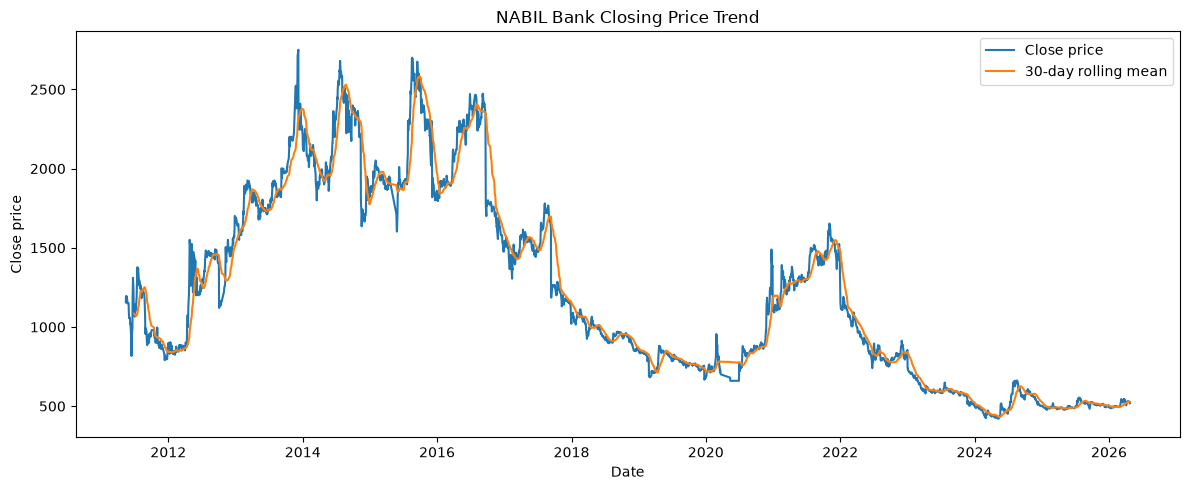

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_02_close_price_trend.png


In [7]:
plt.figure(figsize=(12, 5))
plt.plot(raw["published_date"], raw["close"], label="Close price")
plt.plot(raw["published_date"], raw["close"].rolling(window=30).mean(), label="30-day rolling mean")
plt.xlabel("Date")
plt.ylabel("Close price")
plt.title("NABIL Bank Closing Price Trend")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "figure_eda_02_close_price_trend.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## 8. Trading Activity Over Time

Use this to discuss whether trading activity is stable or whether there are periods with spikes in traded quantity or traded amount.

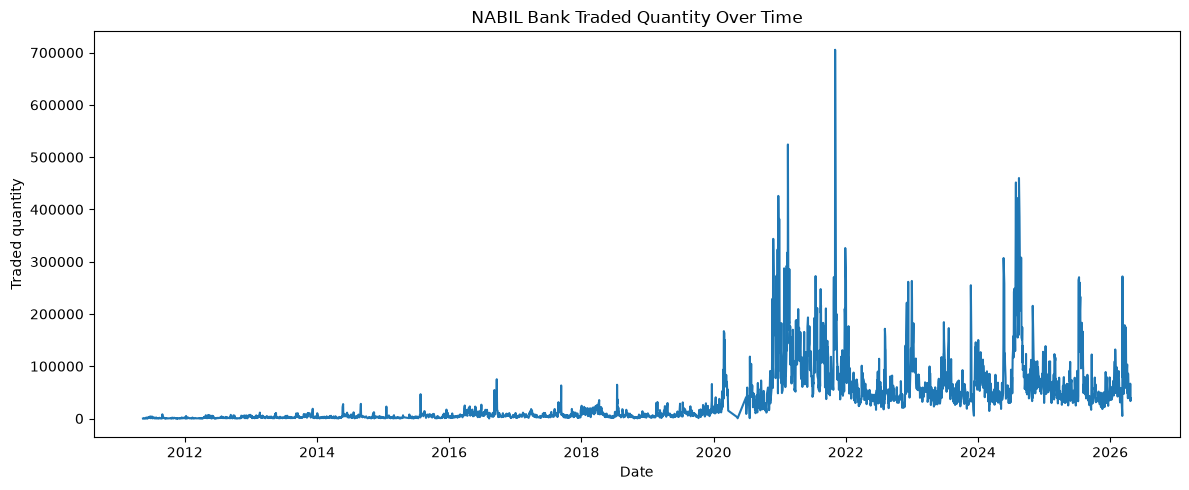

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_03_traded_quantity_trend.png


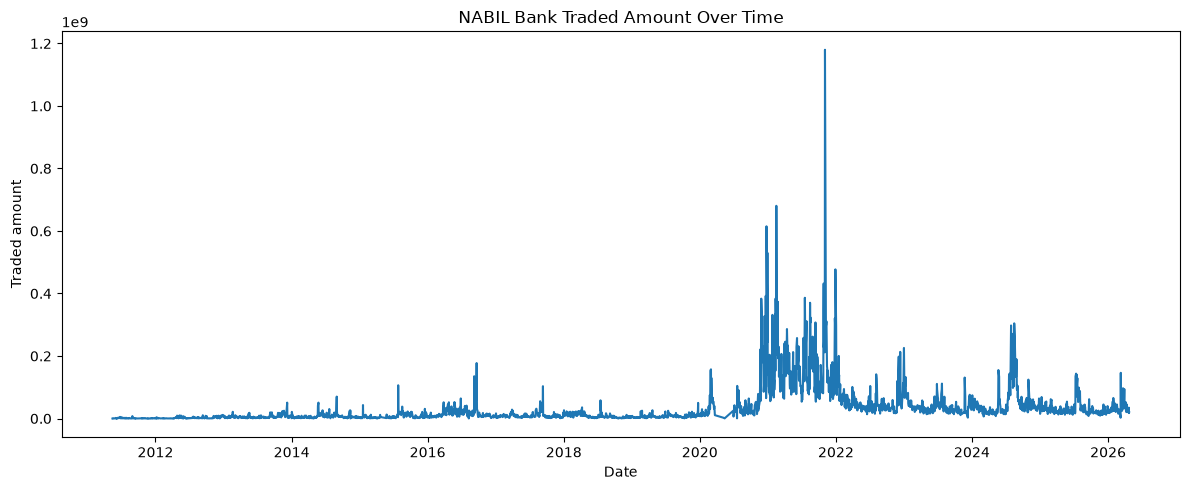

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_04_traded_amount_trend.png


In [8]:
if "traded_quantity" in raw.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(raw["published_date"], raw["traded_quantity"])
    plt.xlabel("Date")
    plt.ylabel("Traded quantity")
    plt.title("NABIL Bank Traded Quantity Over Time")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eda_03_traded_quantity_trend.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

if "traded_amount" in raw.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(raw["published_date"], raw["traded_amount"])
    plt.xlabel("Date")
    plt.ylabel("Traded amount")
    plt.title("NABIL Bank Traded Amount Over Time")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eda_04_traded_amount_trend.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

## 9. Price Distribution

This plot helps show the range and frequency of closing prices in the historical dataset.

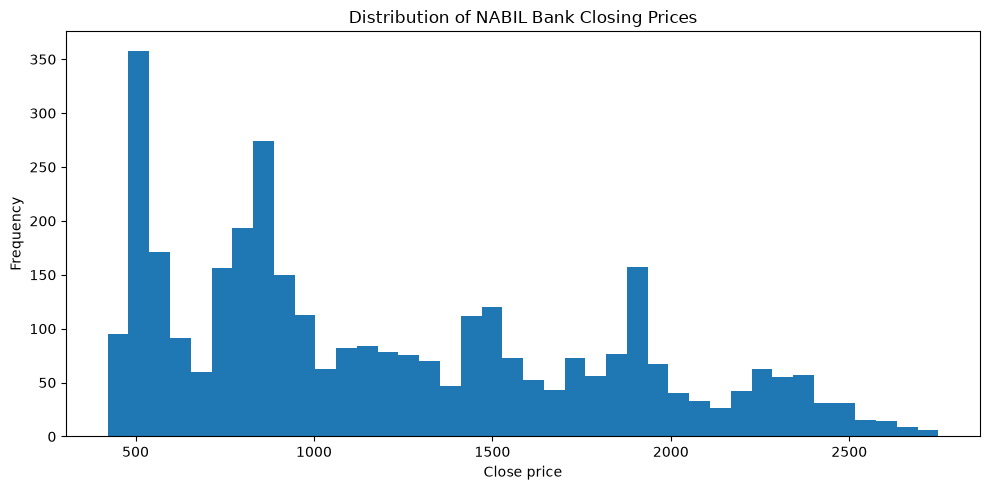

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_05_close_price_distribution.png


In [9]:
plt.figure(figsize=(10, 5))
plt.hist(raw["close"].dropna(), bins=40)
plt.xlabel("Close price")
plt.ylabel("Frequency")
plt.title("Distribution of NABIL Bank Closing Prices")
plt.tight_layout()

fig_path = OUTPUT_DIR / "figure_eda_05_close_price_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## 10. Daily Return Distribution

This supports the discussion of volatility and uncertainty in stock prediction.

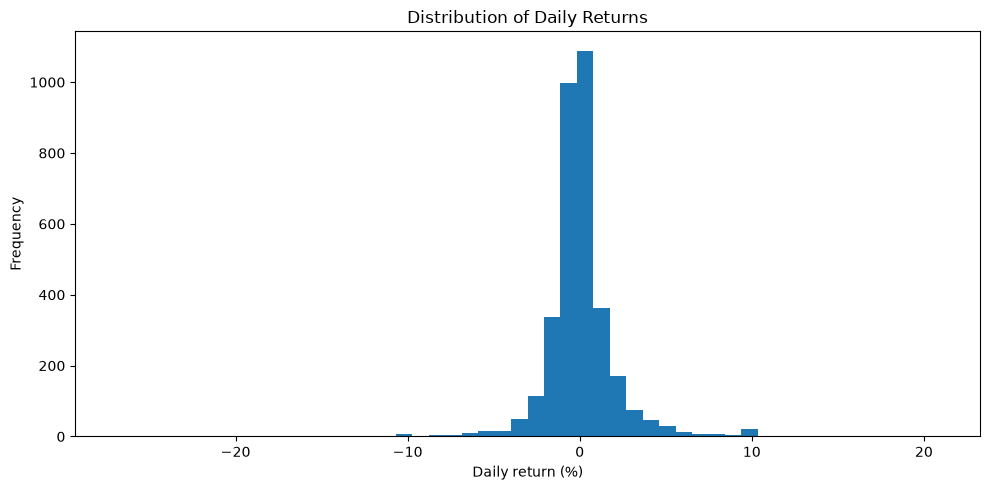

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_06_daily_return_distribution.png
Daily return summary:


,count,mean,std,min,25%,50%,75%,max
daily_return,3387.0,0.027,2.141,-26.93,-0.75,-0.06,0.65,20.87


In [10]:
# Use the engineered daily_return if available; otherwise calculate from raw close price
if "daily_return" in features.columns:
    returns = features["daily_return"].dropna()
else:
    returns = raw["close"].pct_change().dropna() * 100

plt.figure(figsize=(10, 5))
plt.hist(returns, bins=50)
plt.xlabel("Daily return (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")
plt.tight_layout()

fig_path = OUTPUT_DIR / "figure_eda_06_daily_return_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

print("Daily return summary:")
display(returns.describe().to_frame("daily_return").T.round(3))

## 11. Boxplot for Outlier Checking

Boxplots help identify extreme values in price and trading activity variables.

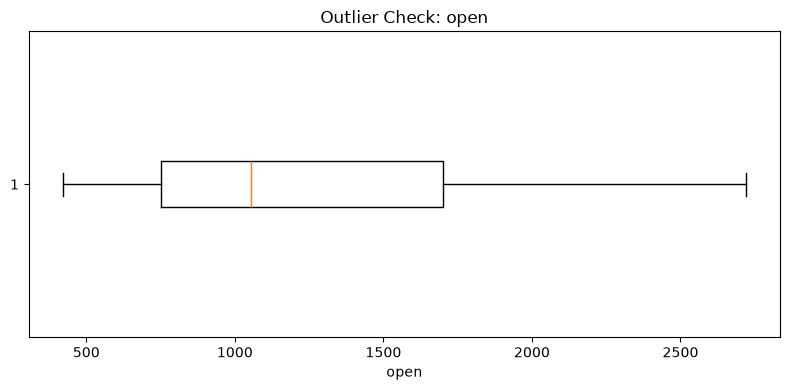

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_07_boxplot_open.png


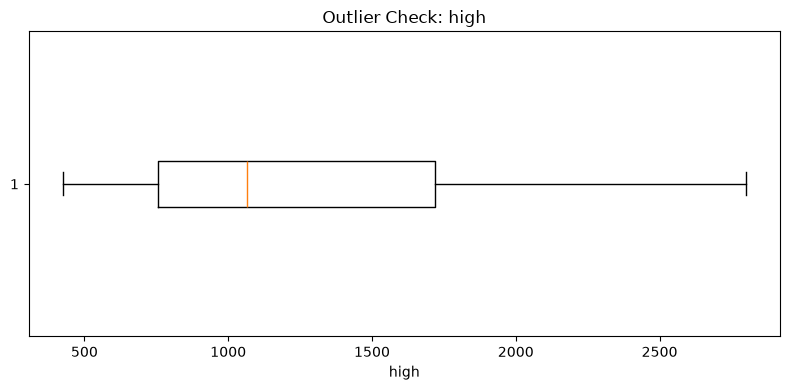

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_07_boxplot_high.png


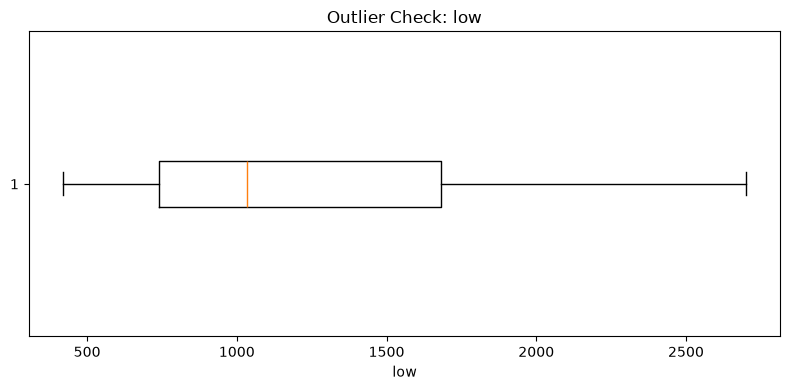

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_07_boxplot_low.png


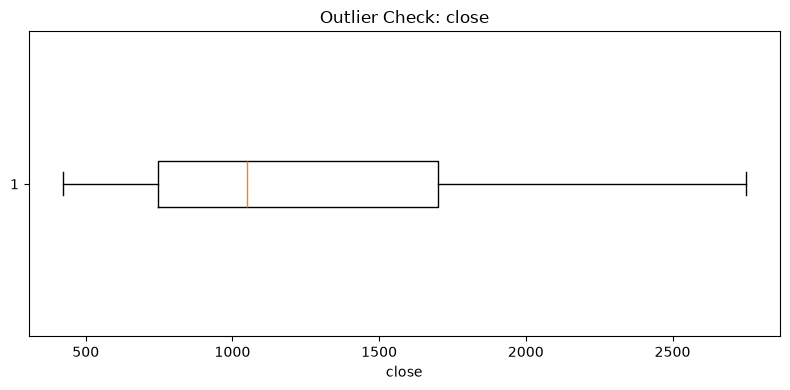

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_07_boxplot_close.png


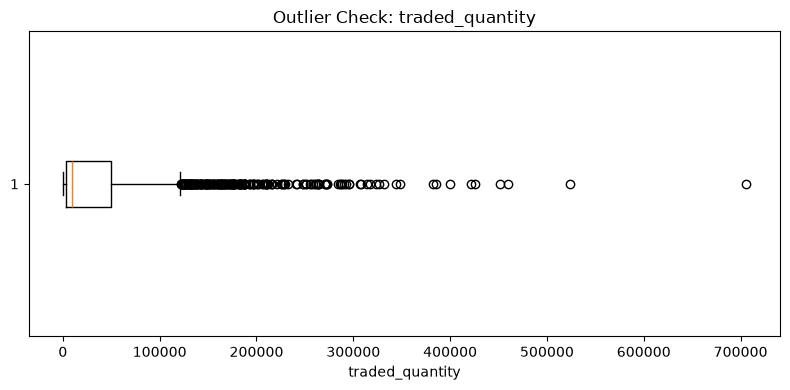

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_07_boxplot_traded_quantity.png


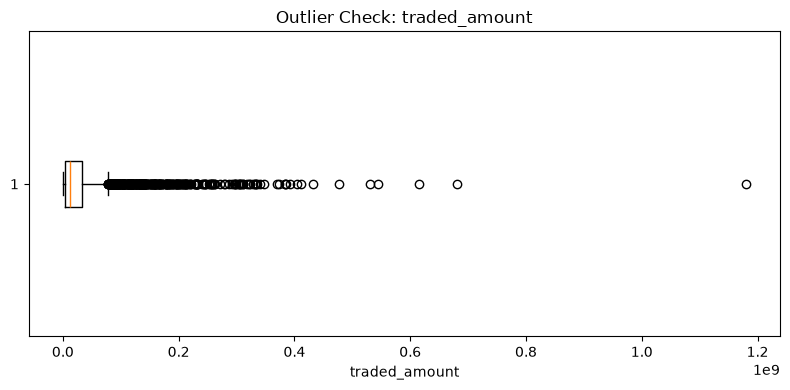

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_07_boxplot_traded_amount.png


In [11]:
box_cols = [col for col in ["open", "high", "low", "close", "traded_quantity", "traded_amount"] if col in raw.columns]

for col in box_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(raw[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Outlier Check: {col}")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / f"figure_eda_07_boxplot_{col}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

## 12. Correlation Heatmap

This is very useful for the report because it shows the relationship between raw prices, engineered features, and the target variable.

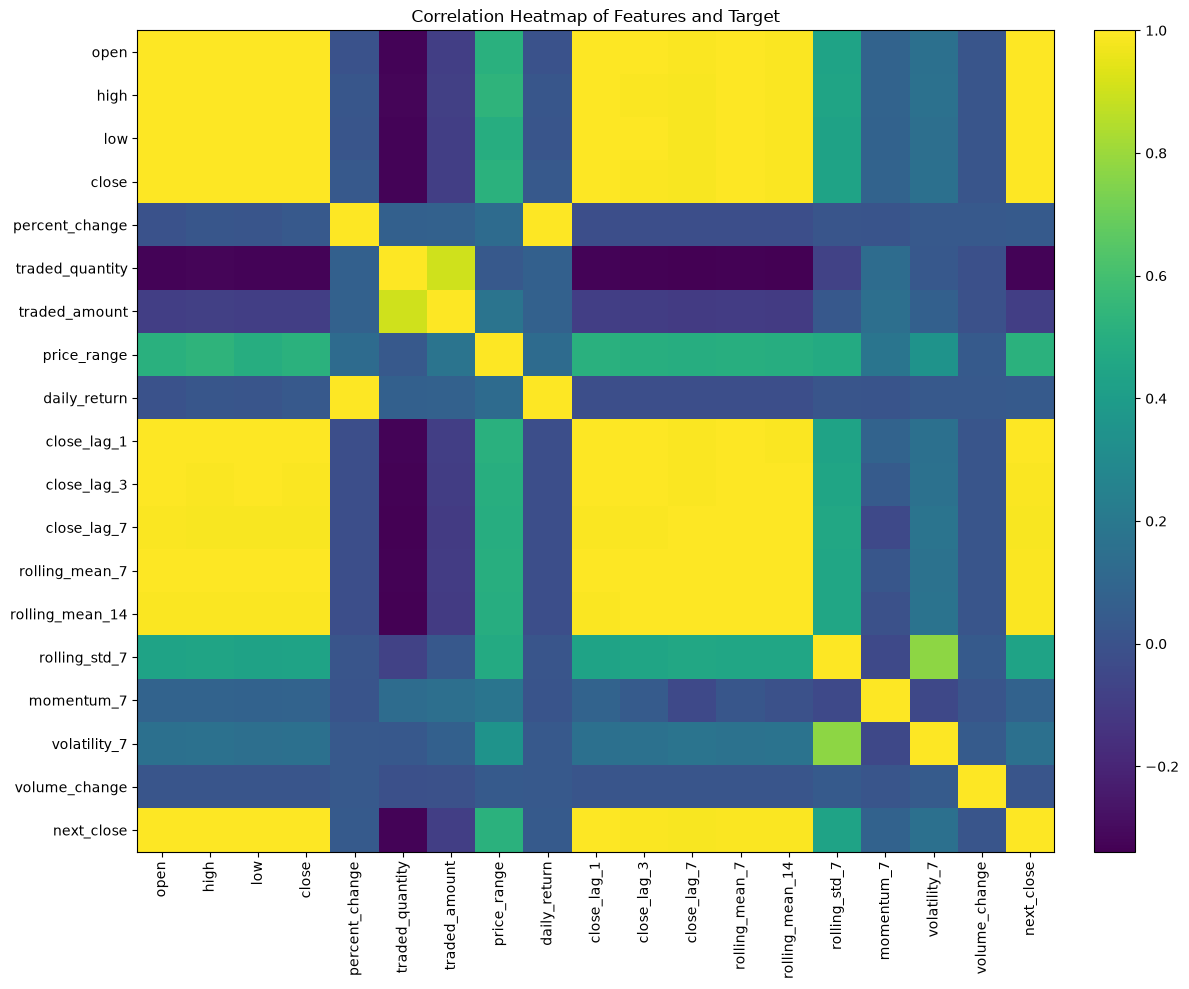

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_08_correlation_heatmap.png


,open,high,low,close,percent_change,traded_quantity,traded_amount,price_range,daily_return,close_lag_1,close_lag_3,close_lag_7,rolling_mean_7,rolling_mean_14,rolling_std_7,momentum_7,volatility_7,volume_change,next_close
open,1.000,0.999,0.999,0.999,-0.004,-0.324,-0.089,0.510,-0.004,0.999,0.996,0.990,0.996,0.993,0.437,0.086,0.154,0.015,0.997
high,0.999,1.000,0.999,1.000,0.022,-0.319,-0.083,0.529,0.022,0.999,0.995,0.989,0.995,0.992,0.443,0.089,0.160,0.016,0.998
low,0.999,0.999,1.000,0.999,0.016,-0.328,-0.093,0.496,0.016,0.999,0.995,0.989,0.996,0.992,0.431,0.083,0.148,0.014,0.998
close,0.999,1.000,0.999,1.000,0.033,-0.324,-0.089,0.516,0.033,0.998,0.995,0.989,0.995,0.992,0.438,0.085,0.155,0.015,0.998
percent_change,-0.004,0.022,0.016,0.033,1.000,0.071,0.079,0.132,1.000,-0.016,-0.019,-0.015,-0.017,-0.018,0.015,0.008,0.037,0.035,0.039
traded_quantity,-0.324,-0.319,-0.328,-0.324,0.071,1.000,0.903,0.033,0.071,-0.325,-0.330,-0.338,-0.332,-0.339,-0.076,0.135,0.031,-0.011,-0.326
traded_amount,-0.089,-0.083,-0.093,-0.089,0.079,0.903,1.000,0.176,0.079,-0.091,-0.097,-0.107,-0.099,-0.107,0.029,0.148,0.069,-0.008,-0.093
price_range,0.510,0.529,0.496,0.516,0.132,0.033,0.176,1.000,0.132,0.510,0.502,0.493,0.501,0.495,0.480,0.181,0.347,0.041,0.515
daily_return,-0.004,0.022,0.016,0.033,1.000,0.071,0.079,0.132,1.000,-0.016,-0.019,-0.015,-0.017,-0.018,0.015,0.008,0.037,0.035,0.039
close_lag_1,0.999,0.999,0.999,0.998,-0.016,-0.325,-0.091,0.510,-0.016,1.000,0.997,0.990,0.997,0.993,0.438,0.086,0.154,0.015,0.997


Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\eda_feature_correlation_matrix.csv


In [12]:
corr_cols = [
    "open", "high", "low", "close", "percent_change", "traded_quantity", "traded_amount",
    "price_range", "daily_return", "close_lag_1", "close_lag_3", "close_lag_7",
    "rolling_mean_7", "rolling_mean_14", "rolling_std_7", "momentum_7", "volatility_7",
    "volume_change", "next_close"
]
corr_cols = [col for col in corr_cols if col in features.columns]

corr = features[corr_cols].corr()

plt.figure(figsize=(12, 10))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap of Features and Target")
plt.tight_layout()

fig_path = OUTPUT_DIR / "figure_eda_08_correlation_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

display(corr.round(3))
corr_path = OUTPUT_DIR / "eda_feature_correlation_matrix.csv"
corr.to_csv(corr_path)
print("Saved:", corr_path)

## 13. Feature Relationship With Target Variable

This chart ranks which numeric features are most strongly correlated with `next_close`.
This is helpful for justifying feature engineering.

,correlation_with_next_close
close,0.998
high,0.998
low,0.998
open,0.997
close_lag_1,0.997
rolling_mean_7,0.994
close_lag_3,0.993
rolling_mean_14,0.990
close_lag_7,0.987
price_range,0.515


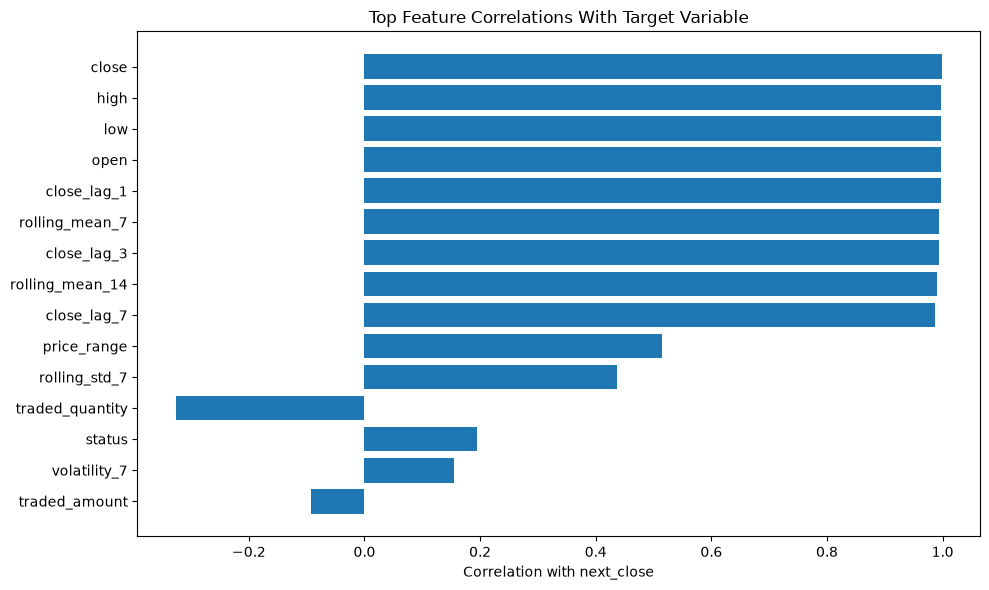

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_09_target_feature_correlations.png


In [13]:
if "next_close" in features.columns:
    numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
    target_corr = features[numeric_cols].corr()["next_close"].drop("next_close", errors="ignore")
    target_corr = target_corr.dropna()

    top_target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).head(15).index)

    display(top_target_corr.to_frame("correlation_with_next_close").round(3))

    plt.figure(figsize=(10, 6))
    plt.barh(top_target_corr.index[::-1], top_target_corr.values[::-1])
    plt.xlabel("Correlation with next_close")
    plt.title("Top Feature Correlations With Target Variable")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eda_09_target_feature_correlations.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    top_target_corr.to_csv(OUTPUT_DIR / "eda_top_target_correlations.csv")
else:
    print("next_close target column not found in processed feature data.")

## 14. Feature vs Target Scatter Plots

Use one or two of these in the report to visually show why lag and rolling features are useful.

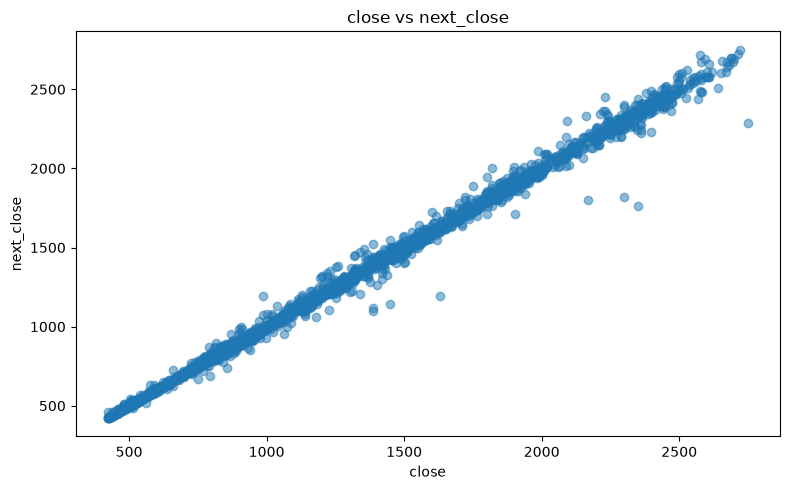

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_10_scatter_close_vs_next_close.png


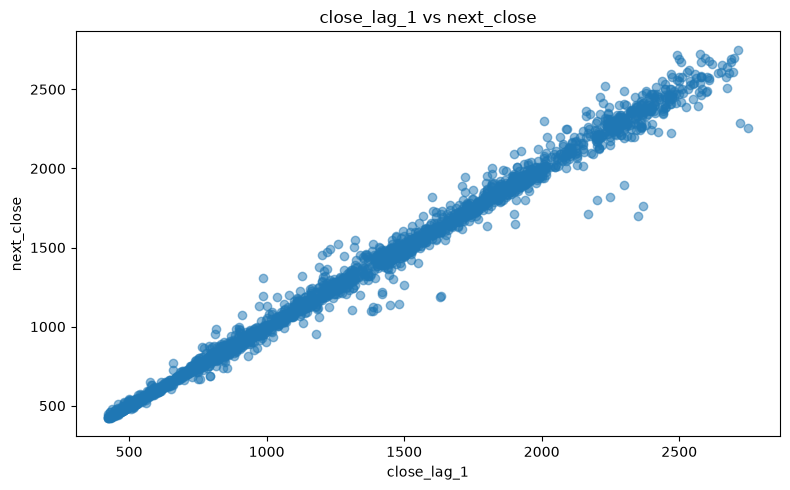

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_10_scatter_close_lag_1_vs_next_close.png


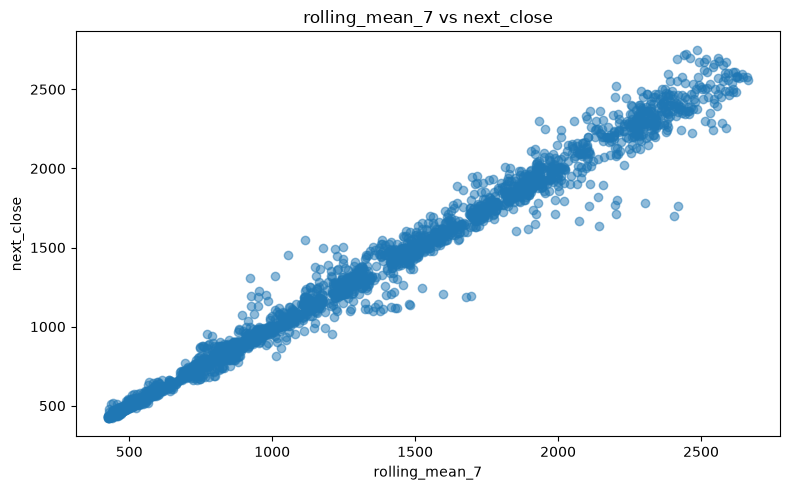

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_10_scatter_rolling_mean_7_vs_next_close.png


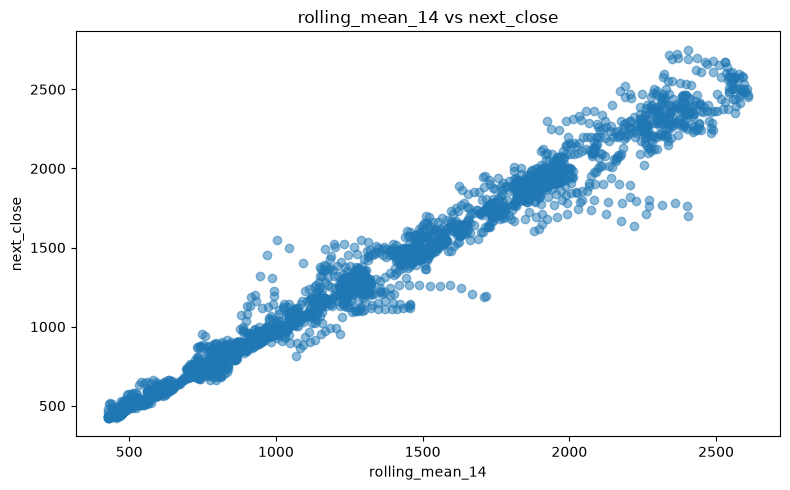

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_10_scatter_rolling_mean_14_vs_next_close.png


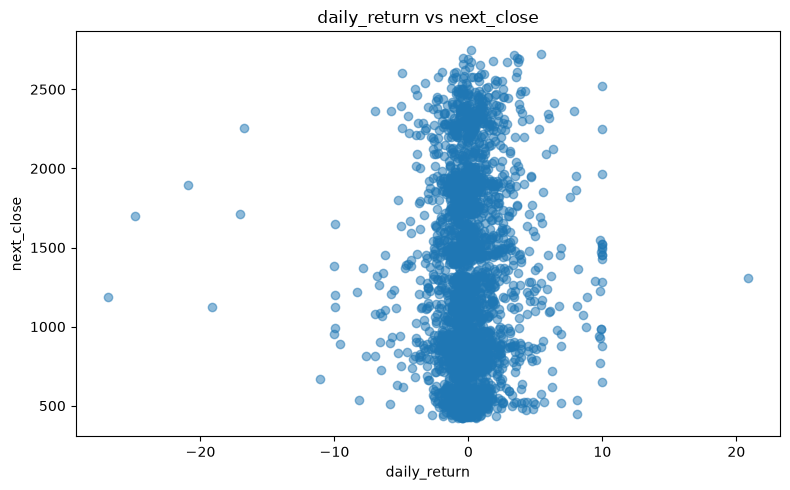

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_10_scatter_daily_return_vs_next_close.png


In [14]:
scatter_pairs = [
    ("close", "next_close"),
    ("close_lag_1", "next_close"),
    ("rolling_mean_7", "next_close"),
    ("rolling_mean_14", "next_close"),
    ("daily_return", "next_close"),
]

for x_col, y_col in scatter_pairs:
    if x_col in features.columns and y_col in features.columns:
        plot_df = features[[x_col, y_col]].dropna()
        plt.figure(figsize=(8, 5))
        plt.scatter(plot_df[x_col], plot_df[y_col], alpha=0.5)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{x_col} vs {y_col}")
        plt.tight_layout()

        fig_path = OUTPUT_DIR / f"figure_eda_10_scatter_{x_col}_vs_{y_col}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", fig_path)

## 15. Autocorrelation of Closing Price

Autocorrelation helps explain why lag features were created for a time-series stock prediction problem.

,lag_days,autocorrelation
0,1,0.998
1,2,0.997
2,3,0.995
3,4,0.993
4,5,0.992
5,6,0.990
6,7,0.989
7,8,0.987
8,9,0.986
9,10,0.984


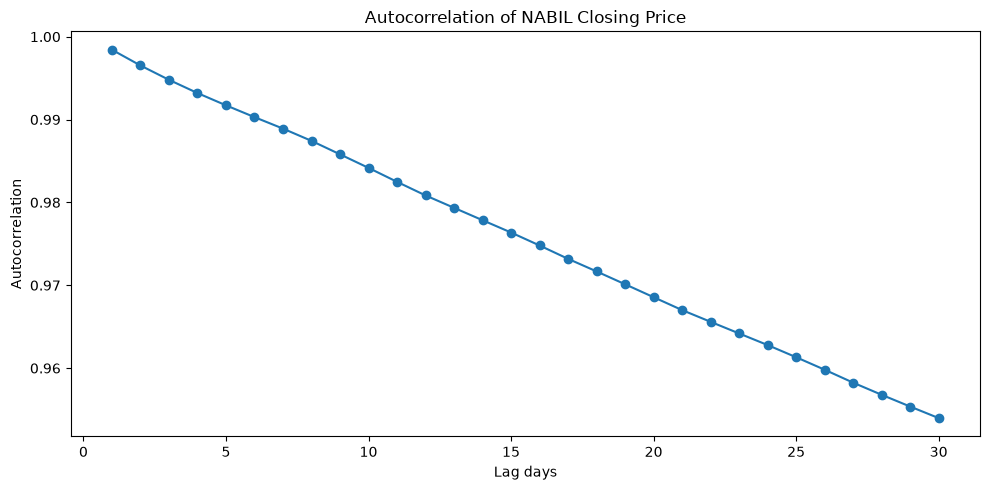

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_11_close_price_autocorrelation.png


In [15]:
lags = list(range(1, 31))
autocorr_values = [raw["close"].autocorr(lag=lag) for lag in lags]

autocorr_df = pd.DataFrame({
    "lag_days": lags,
    "autocorrelation": autocorr_values
})

display(autocorr_df.head(10).round(3))

plt.figure(figsize=(10, 5))
plt.plot(autocorr_df["lag_days"], autocorr_df["autocorrelation"], marker="o")
plt.xlabel("Lag days")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of NABIL Closing Price")
plt.tight_layout()

fig_path = OUTPUT_DIR / "figure_eda_11_close_price_autocorrelation.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

autocorr_df.to_csv(OUTPUT_DIR / "eda_close_price_autocorrelation.csv", index=False)

## 16. Chronological Train/Test Split Check

This is not a full modelling section.  
It visually shows that the data should be split chronologically rather than randomly, because the project uses time-series stock data.

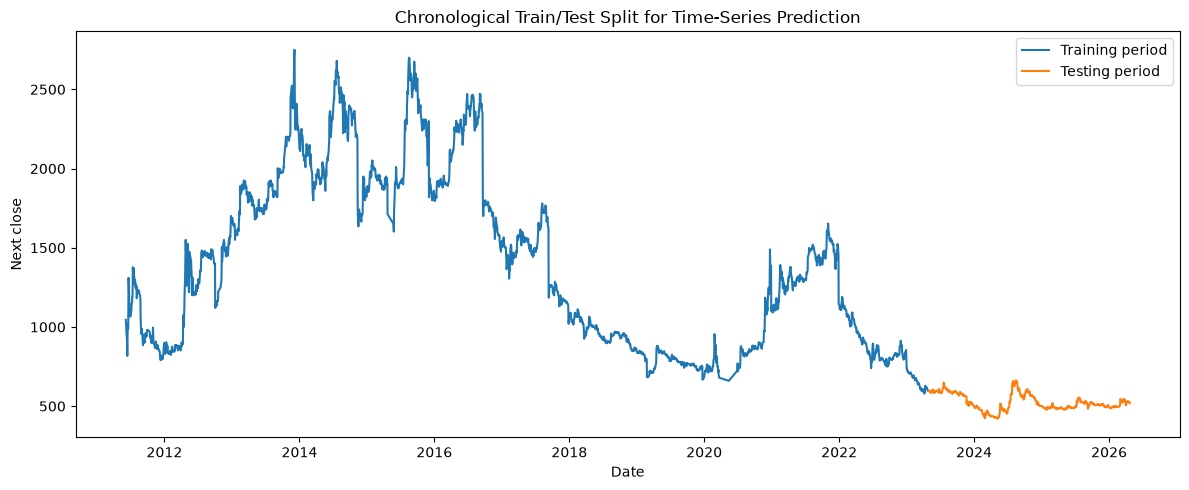

Saved: C:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\eda\figure_eda_12_chronological_train_test_split.png


In [16]:
if "next_close" in features.columns:
    split_index = int(len(features) * 0.8)
    train_part = features.iloc[:split_index]
    test_part = features.iloc[split_index:]

    plt.figure(figsize=(12, 5))
    plt.plot(train_part["published_date"], train_part["next_close"], label="Training period")
    plt.plot(test_part["published_date"], test_part["next_close"], label="Testing period")
    plt.xlabel("Date")
    plt.ylabel("Next close")
    plt.title("Chronological Train/Test Split for Time-Series Prediction")
    plt.legend()
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eda_12_chronological_train_test_split.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

# Optional Model Evaluation Figures

Your report already has model metrics, but these figures can make the model evaluation section stronger.  
Use these after Section 6.1 Model Training, or in Section 9 Evaluation.

## 17. Actual vs Predicted and Residual Analysis

This section trains a quick Linear Regression model using the processed feature table and a chronological split.
It creates:

- Actual vs predicted line plot
- Actual vs predicted scatter plot
- Residual distribution
- Residuals over time

These figures are stronger than only showing MAE, RMSE, and R².

In [17]:
try:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    candidate_features = [
        "open", "high", "low", "close", "traded_quantity", "traded_amount",
        "price_range", "daily_return", "close_lag_1", "close_lag_3", "close_lag_7",
        "rolling_mean_7", "rolling_mean_14", "rolling_std_7",
        "return_lag_1", "return_lag_3", "return_lag_7",
        "momentum_7", "volatility_7", "volume_change"
    ]
    model_features = [col for col in candidate_features if col in features.columns]
    target_col = "next_close"

    model_df = features[["published_date"] + model_features + [target_col]].dropna().sort_values("published_date")

    split_index = int(len(model_df) * 0.8)
    train_df = model_df.iloc[:split_index]
    test_df = model_df.iloc[split_index:]

    X_train = train_df[model_features]
    y_train = train_df[target_col]
    X_test = test_df[model_features]
    y_test = test_df[target_col]

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    eval_metrics = pd.DataFrame({
        "metric": ["MAE", "RMSE", "R2"],
        "value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred, squared=False),
            r2_score(y_test, y_pred)
        ]
    })

    display(eval_metrics.round(4))
    eval_metrics.to_csv(OUTPUT_DIR / "eda_linear_regression_evaluation_metrics.csv", index=False)

    pred_df = pd.DataFrame({
        "published_date": test_df["published_date"].values,
        "actual_next_close": y_test.values,
        "predicted_next_close": y_pred,
        "residual": y_test.values - y_pred
    })

    display(pred_df.head())
    pred_df.to_csv(OUTPUT_DIR / "eda_actual_vs_predicted_values.csv", index=False)

    # Actual vs Predicted over time
    plt.figure(figsize=(12, 5))
    plt.plot(pred_df["published_date"], pred_df["actual_next_close"], label="Actual next_close")
    plt.plot(pred_df["published_date"], pred_df["predicted_next_close"], label="Predicted next_close")
    plt.xlabel("Date")
    plt.ylabel("Next close")
    plt.title("Actual vs Predicted Next Closing Price")
    plt.legend()
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eval_01_actual_vs_predicted_line.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    # Actual vs Predicted scatter
    plt.figure(figsize=(7, 7))
    plt.scatter(pred_df["actual_next_close"], pred_df["predicted_next_close"], alpha=0.5)
    min_val = min(pred_df["actual_next_close"].min(), pred_df["predicted_next_close"].min())
    max_val = max(pred_df["actual_next_close"].max(), pred_df["predicted_next_close"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual next_close")
    plt.ylabel("Predicted next_close")
    plt.title("Actual vs Predicted Scatter Plot")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eval_02_actual_vs_predicted_scatter.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    # Residual histogram
    plt.figure(figsize=(10, 5))
    plt.hist(pred_df["residual"], bins=40)
    plt.xlabel("Residual: actual - predicted")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eval_03_residual_distribution.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    # Residuals over time
    plt.figure(figsize=(12, 5))
    plt.plot(pred_df["published_date"], pred_df["residual"])
    plt.axhline(0, linestyle="--")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title("Residuals Over Time")
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "figure_eval_04_residuals_over_time.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

except ImportError:
    print("scikit-learn is not installed. Install it with: pip install scikit-learn")
except Exception as e:
    print("Could not run optional model evaluation section.")
    print("Error:", e)

Could not run optional model evaluation section.
Error: got an unexpected keyword argument 'squared'


## 18. Automatically Generated EDA Summary for Report Drafting

This creates a short text file with data-specific observations.  
After running the notebook, open `reports/figures/eda/eda_summary_for_report.txt` and adapt the wording into your report using your own academic style.

In [18]:
summary_lines = []

# Basic dataset details
summary_lines.append("Exploratory Data Analysis Summary")
summary_lines.append("=" * 40)
summary_lines.append(f"Raw NABIL dataset contains {len(raw)} rows and {raw.shape[1]} columns.")
summary_lines.append(f"The raw dataset covers the period from {raw['published_date'].min().date()} to {raw['published_date'].max().date()}.")
summary_lines.append(f"The processed feature dataset contains {len(features)} rows and {features.shape[1]} columns.")

# Missing values
raw_missing_total = int(raw.isna().sum().sum())
feature_missing_total = int(features.isna().sum().sum())
summary_lines.append(f"The raw dataset contains {raw_missing_total} missing cells.")
summary_lines.append(f"The processed dataset contains {feature_missing_total} missing cells; any missing values should be checked against lag and rolling-window feature creation.")

# Close price movement
first_close = raw["close"].dropna().iloc[0]
last_close = raw["close"].dropna().iloc[-1]
close_change = last_close - first_close
close_change_pct = (close_change / first_close) * 100 if first_close != 0 else np.nan
summary_lines.append(f"The closing price changed from {first_close:.2f} to {last_close:.2f}, a change of {close_change:.2f} ({close_change_pct:.2f}%).")

# Trading activity peak
if "traded_quantity" in raw.columns and raw["traded_quantity"].notna().any():
    idx = raw["traded_quantity"].idxmax()
    summary_lines.append(f"The highest traded quantity was observed on {raw.loc[idx, 'published_date'].date()} with {raw.loc[idx, 'traded_quantity']:.0f} units.")

if "traded_amount" in raw.columns and raw["traded_amount"].notna().any():
    idx = raw["traded_amount"].idxmax()
    summary_lines.append(f"The highest traded amount was observed on {raw.loc[idx, 'published_date'].date()} with {raw.loc[idx, 'traded_amount']:.2f}.")

# Target correlations
if "next_close" in features.columns:
    numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
    target_corr = features[numeric_cols].corr()["next_close"].drop("next_close", errors="ignore").dropna()
    top_corr = target_corr.abs().sort_values(ascending=False).head(5)
    summary_lines.append("The strongest absolute correlations with next_close were:")
    for feature_name, corr_value in top_corr.items():
        summary_lines.append(f"- {feature_name}: {target_corr[feature_name]:.3f}")

summary_lines.append("")
summary_lines.append("Recommended report figures:")
summary_lines.append("1. Closing price trend over time")
summary_lines.append("2. Trading quantity or traded amount over time")
summary_lines.append("3. Correlation heatmap")
summary_lines.append("4. Feature correlation with next_close")
summary_lines.append("5. Actual vs predicted plot or residual distribution in the model evaluation section")

summary_text = "\n".join(summary_lines)
print(summary_text)

summary_path = OUTPUT_DIR / "eda_summary_for_report.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved:", summary_path)

Exploratory Data Analysis Summary
Raw NABIL dataset contains 3413 rows and 9 columns.
The raw dataset covers the period from 2011-05-15 to 2026-04-24.
The processed feature dataset contains 3387 rows and 27 columns.
The raw dataset contains 1 missing cells.
The processed dataset contains 0 missing cells; any missing values should be checked against lag and rolling-window feature creation.
The closing price changed from 1155.00 to 518.00, a change of -637.00 (-55.15%).
The highest traded quantity was observed on 2021-11-03 with 705430 units.
The highest traded amount was observed on 2021-11-03 with 1179786179.70.
The strongest absolute correlations with next_close were:
- close: 0.998
- high: 0.998
- low: 0.998
- open: 0.997
- close_lag_1: 0.997

Recommended report figures:
1. Closing price trend over time
2. Trading quantity or traded amount over time
3. Correlation heatmap
4. Feature correlation with next_close
5. Actual vs predicted plot or residual distribution in the model evaluati

# Final Checklist Before Adding EDA to the Report

Use this notebook to generate figures, but select only the best ones for the report.

Recommended figures for the report:

1. **NABIL closing price trend**  
2. **Trading activity over time**  
3. **Correlation heatmap**  
4. **Top correlations with `next_close`**  
5. **Actual vs predicted plot** in model evaluation  
6. **Residual distribution** in model evaluation  

Recommended table:

- Dataset overview table  
- Missing value summary  
- Descriptive statistics table, but keep it short in the report

Using feature file: c:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\data\processed\nabil_features.csv
Evaluation Metrics
MAE:  9.07 NPR
RMSE: 11.64 NPR
R²:   0.9501


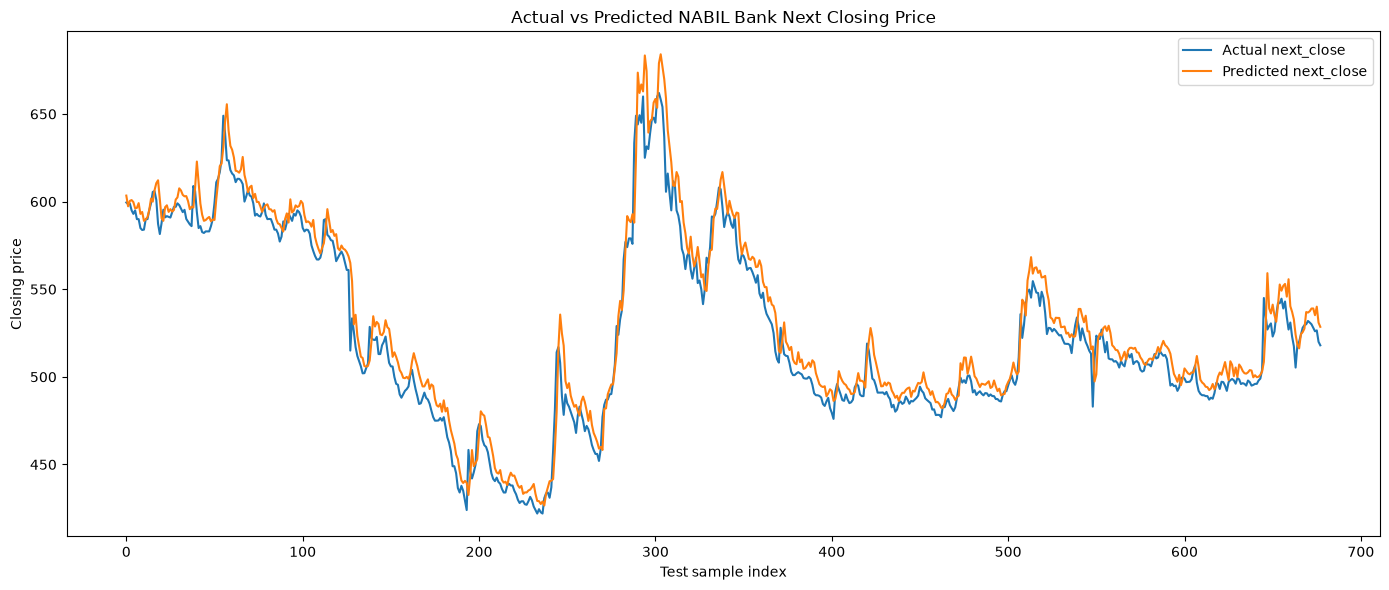

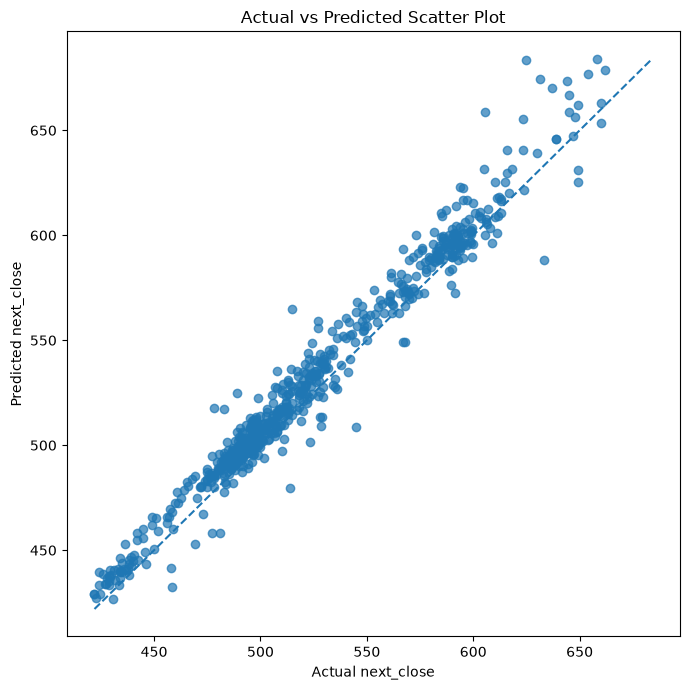

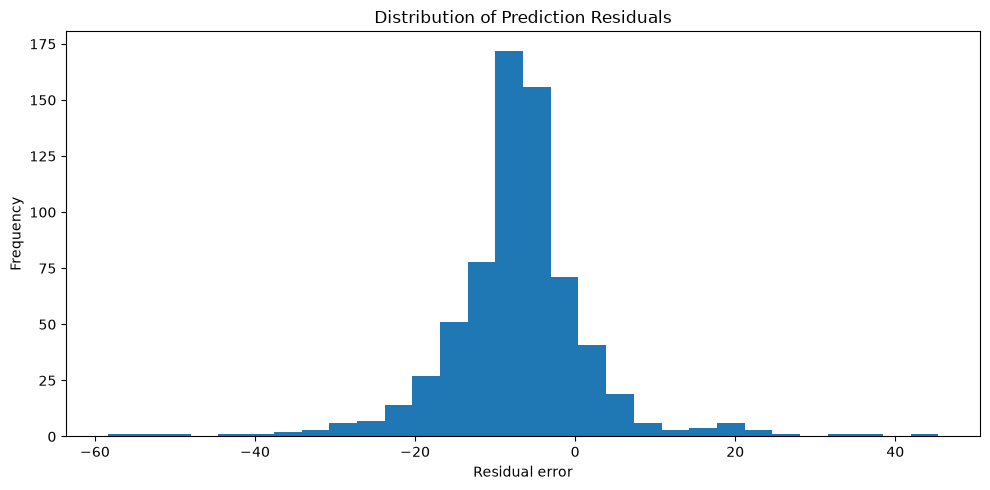

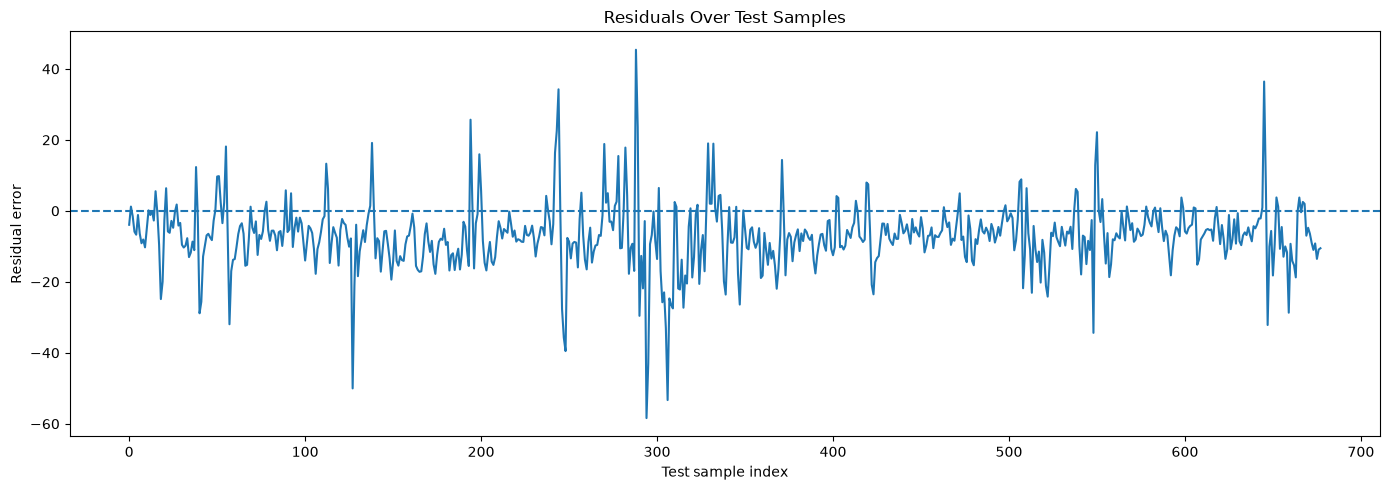


Saved evaluation outputs to:
c:\Users\Lenovo\OneDrive - Birmingham City University\Desktop\nepse-ml-pipeline\reports\figures\model_evaluation


In [19]:
# ============================================================
# Model Evaluation Plots: Actual vs Predicted and Residuals
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Locate project root and processed feature file
# ------------------------------------------------------------

current_dir = Path.cwd()

# If notebook is inside /notebooks, go one level up
if current_dir.name.lower() == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

possible_feature_paths = [
    project_root / "data" / "processed" / "nabil_features.csv",
    project_root / "data" / "processed" / "processed_nabil_features.csv",
    project_root / "data" / "processed" / "nabil_processed_features.csv",
    project_root / "data" / "processed_nabil_features.csv",
]

feature_path = None
for path in possible_feature_paths:
    if path.exists():
        feature_path = path
        break

if feature_path is None:
    raise FileNotFoundError(
        "Could not find processed feature CSV. "
        "Check your file name inside data/processed/."
    )

print(f"Using feature file: {feature_path}")

df = pd.read_csv(feature_path)

# ------------------------------------------------------------
# 2. Prepare data
# ------------------------------------------------------------

# Convert date if available
if "published_date" in df.columns:
    df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
    df = df.sort_values("published_date").reset_index(drop=True)

target_col = "next_close"

if target_col not in df.columns:
    raise ValueError("Target column 'next_close' not found in the processed dataset.")

# Columns that should not be used as training features
exclude_cols = [
    "symbol",
    "published_date",
    "next_close",
    "target_change",
    "target_pct_change",
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])
]

model_df = df[feature_cols + [target_col]].dropna().copy()

X = model_df[feature_cols]
y = model_df[target_col]

# Chronological train/test split
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# ------------------------------------------------------------
# 3. Train Linear Regression model
# ------------------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test.values - y_pred

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics")
print(f"MAE:  {mae:.2f} NPR")
print(f"RMSE: {rmse:.2f} NPR")
print(f"R²:   {r2:.4f}")

# ------------------------------------------------------------
# 4. Create output folder
# ------------------------------------------------------------

eval_dir = project_root / "reports" / "figures" / "model_evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 5. Actual vs Predicted Line Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label="Actual next_close")
plt.plot(y_pred, label="Predicted next_close")
plt.title("Actual vs Predicted NABIL Bank Next Closing Price")
plt.xlabel("Test sample index")
plt.ylabel("Closing price")
plt.legend()
plt.tight_layout()

line_plot_path = eval_dir / "figure_eval_01_actual_vs_predicted_line.png"
plt.savefig(line_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Actual vs Predicted Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs Predicted Scatter Plot")
plt.xlabel("Actual next_close")
plt.ylabel("Predicted next_close")
plt.tight_layout()

scatter_plot_path = eval_dir / "figure_eval_02_actual_vs_predicted_scatter.png"
plt.savefig(scatter_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 7. Residual Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual error")
plt.ylabel("Frequency")
plt.tight_layout()

residual_dist_path = eval_dir / "figure_eval_03_residual_distribution.png"
plt.savefig(residual_dist_path, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 8. Residuals Over Time
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals Over Test Samples")
plt.xlabel("Test sample index")
plt.ylabel("Residual error")
plt.tight_layout()

residual_time_path = eval_dir / "figure_eval_04_residuals_over_time.png"
plt.savefig(residual_time_path, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9. Save actual vs predicted values as CSV
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "actual_next_close": y_test.values,
    "predicted_next_close": y_pred,
    "residual": residuals
})

results_csv_path = eval_dir / "actual_vs_predicted_results.csv"
results_df.to_csv(results_csv_path, index=False)

print("\nSaved evaluation outputs to:")
print(eval_dir)